In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/customer_churn_business_dataset.csv')

display(df.head())

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [3]:
print("--- 1. STRUCTURE DU DATASET ---")
print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")

print("--- 2. TYPES DE VARIABLES ET VALEURS NON NULLES ---")
df.info()

print("\n--- 3. VALEURS MANQUANTES (NaN) ---")
missing_values = df.isna().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Aucune valeur manquante détectée.")

print("\n--- 4. DOUBLONS STRICTS ---")
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")

--- 1. STRUCTURE DU DATASET ---
Dimensions : 10000 lignes et 32 colonnes

--- 2. TYPES DE VARIABLES ET VALEURS NON NULLES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used      

### 6.2. Diagnostic de la Variable Cible (Churn)

**Analyse visuelle :**
Le graphique en barres met en évidence un net déséquilibre des classes (Class Imbalance) au sein de notre jeu de données. Une large majorité des clients est fidèle (classe `0`), tandis que la proportion de clients ayant résilié (classe `1`) représente une minorité (autour de 20% de la base).

**Conclusion Technique & Métier :**
* **Technique :** Ce déséquilibre est une information capitale pour la suite du projet. Il nous indique que la métrique d'évaluation classique (l'*Accuracy* ou Précision Globale) sera trompeuse. Un modèle qui prédirait naïvement que "personne ne part jamais" aurait d'office un score de 80%, sans résoudre notre problème. Il faudra donc privilégier le **F1-Score** et le **Rappel (Recall)** lors de la modélisation, et potentiellement utiliser une technique de rééquilibrage (comme SMOTE) lors du preprocessing.
* **Métier :** Un taux de churn naturel autour de 20% est classique dans les services par abonnement, mais représente une perte de chiffre d'affaires (Revenu à Risque) colossale à l'échelle de l'entreprise.

/var/folders/_4/jrm4bct12mbb49wpl6t1y9qh0000gn/T/ipykernel_97194/10950864.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='churn', palette=['#2ecc71', '#e74c3c'])


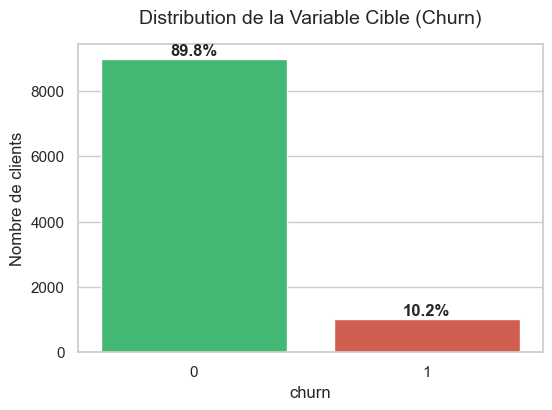

In [4]:
# 1. Analyse de la Variable Cible (Target) : Churn
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution de la Variable Cible (Churn)', fontsize=14, pad=15)
plt.ylabel('Nombre de clients')

# Ajout des pourcentages sur les barres
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')
plt.show()

### 6.3\. Analyse des Variables Numériques Continues (Distributions)

Cette section explore la forme des distributions de nos variables numériques continues. L'objectif est de comprendre la démographie et les comportements d'usage globaux de notre base d'utilisateurs, indépendamment du _churn_.

**Analyse visuelle et Interprétation Métier :**

*   **age (Âge) :** La distribution de l'âge est remarquablement **uniforme** et symétrique (autour d'une moyenne de 43 ans). Cela indique que le service attire une clientèle très diversifiée sur le plan générationnel, sans cibler une tranche d'âge spécifique.
    
*   **tenure\_months (Ancienneté) :** La distribution de l'ancienneté est relativement **plate**, avec de légères baisses aux deux extrêmes. Cela montre un flux d'acquisition constant, sans pic majeur de nouveaux entrants ou de rétention historique massive.
    
*   **monthly\_logins & weekly\_active\_days (Engagement d'Usage) :**
    
    *   Les connexions mensuelles forment une belle courbe normale centrée autour de 15 connexions par mois.
        
    *   Les jours actifs par semaine suivent une légère asymétrie vers la droite (biais positif), avec un pic à 3 jours par semaine.
        
    *   _Insight :_ L'utilisateur moyen se connecte environ un jour sur deux. Ce n'est donc pas un service à usage quotidien intensif pour la majorité.
        
*   **avg\_session\_time (Temps de Session) :** La distribution est asymétrique vers la gauche (biais négatif), avec une forte concentration de sessions autour de 20 à 30 minutes. Les sessions très courtes sont rares, indiquant que lorsque les utilisateurs se connectent, ils y passent un temps significatif.
    
*   **features\_used (Fonctionnalités Utilisées) :** La distribution est normale et centrée sur 10. L'adoption des fonctionnalités est donc modérée et standardisée.
    
*   **usage\_growth\_rate (Taux de Croissance de l'Usage) :** La distribution est normale et centrée sur 0. Cela signifie que l'usage de la majorité des clients stagne (ni augmentation, ni baisse). C'est un point de vigilance pour l'équipe Produit : il y a peu d'effet "viral" ou d'adoption croissante avec le temps.
    
*   **last\_login\_days\_ago (Dernière Connexion) :** La distribution est normale et centrée autour de 15 jours. Une grande partie de la base d'utilisateurs ne s'est pas connectée depuis deux semaines, ce qui pourrait être un signal précurseur de _churn_.
    
*   **monthly\_fee & total\_revenue (Variables Financières) :**
    
    *   Les frais mensuels sont distribués très uniformément entre les différents paliers tarifaires.
        
    *   Le revenu total présente une asymétrie vers la droite (biais positif), ce qui est mathématiquement logique : une majorité de clients a un revenu cumulé modéré (tenure faible/moyenne), tandis qu'une minorité (les clients très anciens) tire la courbe vers des valeurs élevées.
        
*   **payment\_failures (Échecs de Paiement) :** La distribution montre que la majorité des clients n'ont aucun ou très peu d'échecs de paiement (pic à 0 ou 1). Les clients avec de multiples échecs sont très minoritaires.
    
*   **support\_tickets & avg\_resolution\_time (Support Client) :**
    
    *   Les tickets ouverts sont répartis autour d'une moyenne de 2 à 3, sans queue de distribution longue.
        
    *   Le temps de résolution est asymétrique vers la droite, indiquant que la plupart des problèmes sont résolus rapidement (pic à < 20 heures), mais avec quelques cas complexes qui traînent.
        
*   **csat\_score & nps\_score (Satisfaction) :**
    
    *   Le CSAT (Satisfaction Immédiate) est asymétrique vers la gauche (biais négatif), ce qui est positif : une grande majorité donne des notes élevées (4 ou 5).
        
    *   Cependant, le NPS (Recommandation) est centré autour de 0, avec une distribution normale.
        
    *   _Insight crucial :_ Les clients sont globalement satisfaits du produit (CSAT élevé), mais ils ne sont pas des "promoteurs" enthousiastes prêts à le recommander (NPS neutre).
        

**Conclusion Technique pour la Modélisation :**La plupart des variables présentent des distributions proches de la normale ou des distributions uniformes, sans asymétrie extrême (skewness forte) nécessitant une transformation logarithmique urgente. L'utilisation d'algorithmes robustes basés sur les arbres (comme Random Forest ou XGBoost) sera bien adaptée à ces données brutes, car ces modèles sont peu sensibles aux échelles et aux formes exactes des distributions.


Variables numériques détectées : ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count']


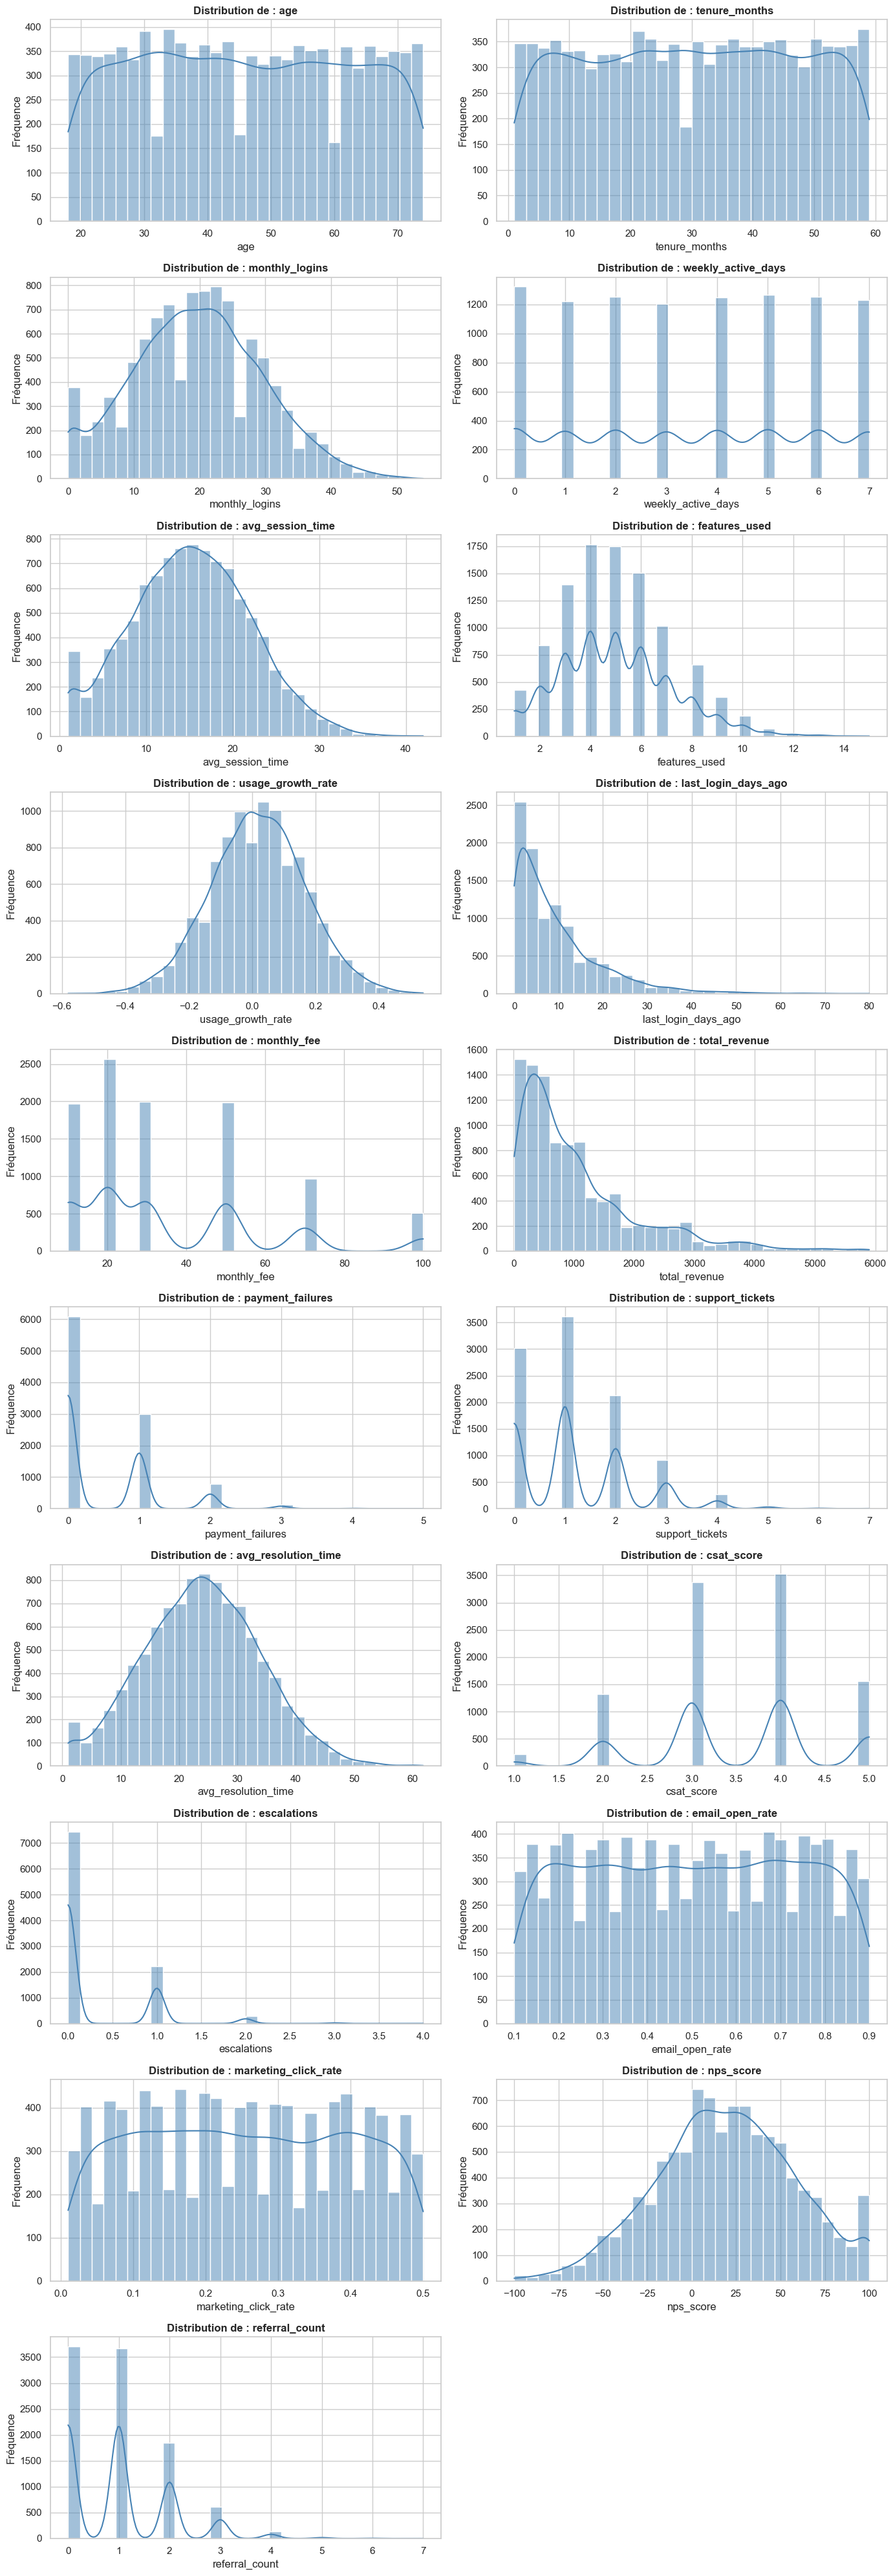

In [5]:
# 6.3. Analyse des variables numériques continues
# On sélectionne automatiquement les colonnes numériques
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# On exclut la target si elle est déjà encodée en 0/1
if 'churn' in num_cols: num_cols.remove('churn') 

print(f"\nVariables numériques détectées : {num_cols}")

# Affichage des distributions avec la courbe de densité (KDE)
fig, axes = plt.subplots(nrows=(len(num_cols) + 1) // 2, ncols=2, figsize=(14, 4 * ((len(num_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribution de : {col}', fontweight='bold')
    axes[i].set_ylabel('Fréquence')

# Cacher les graphiques vides si le nombre de variables est impair
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

### 6.4. Analyse de la Dispersion et Détection des Valeurs Extrêmes (Outliers)

**Analyse visuelle :**
Les boîtes à moustaches (boxplots) révèlent la dispersion de nos variables financières (`monthly_fee`, `total_revenue`) et d'usage (`avg_session_time`). 
* On remarque la présence de valeurs extrêmes (points situés au-delà des moustaches supérieures), en particulier sur le `total_revenue`.

**Conclusion Métier & Technique :**
Contrairement à des erreurs de capteurs physiques, ces valeurs "aberrantes" statistiquement sont **tout à fait valides d'un point de vue métier**. Un revenu total exceptionnellement élevé indique simplement un client de très longue date ou ayant souscrit à de nombreuses options ("Client Premium"). 
* **Décision :** Nous ne supprimerons pas ces outliers. Au contraire, ce sont précisément ces clients à très haute Valeur à Vie (LTV) qu'il faut à tout prix empêcher de "churner", car leur impact sur le Revenu à Risque est disproportionné.

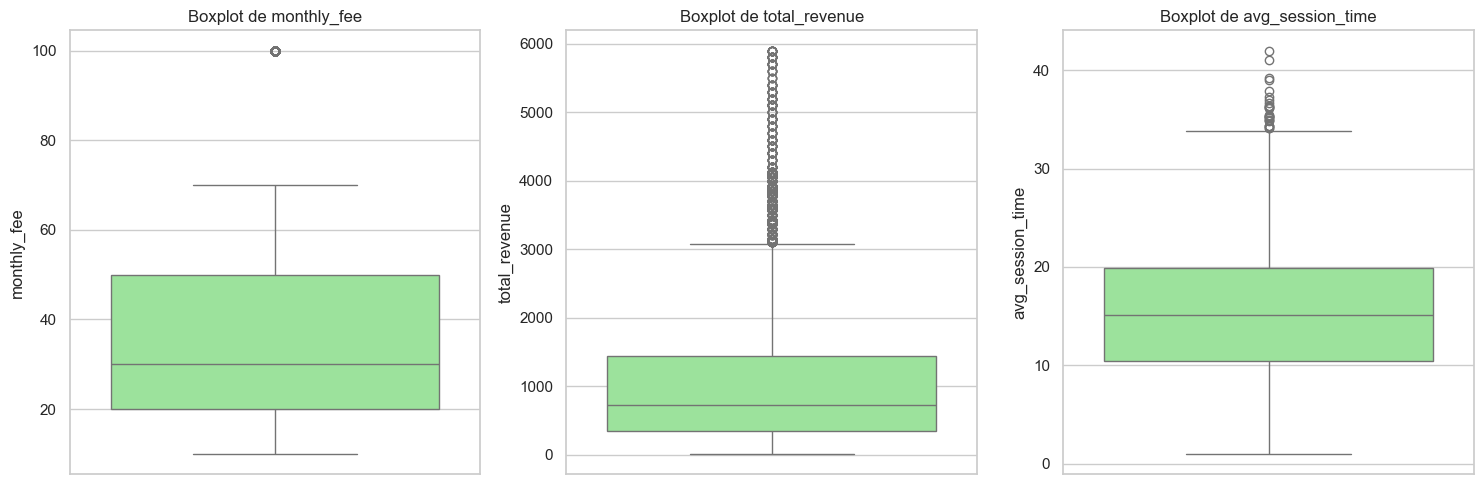

In [25]:
# Sélection de variables financières et d'engagement
colonnes_outliers = ['monthly_fee', 'total_revenue', 'avg_session_time']

plt.figure(figsize=(15, 5))
for i, col in enumerate(colonnes_outliers, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

### 6.5. Analyse Bivariée : Quels comportements pilotent le Churn ?

**Analyse visuelle & Interprétation :**
* **Type de Contrat (`contract_type`) :** Le graphique en barres empilées est sans appel. La quasi-totalité des clients qui résilient sont sous un contrat "Month-to-month" (sans engagement). À l'inverse, les clients ayant signé pour un ou deux ans ont un taux d'attrition extrêmement faible. L'engagement contractuel est le principal bouclier contre le churn.
* **Support Client (`support_tickets`) :** Les boxplots montrent que la médiane et les quartiles supérieurs des tickets ouverts sont plus élevés chez les "churners". Un volume élevé d'appels au support est un signal d'alarme (insatisfaction technique ou produit).
* **Frais Mensuels (`monthly_fee`) :** La courbe de densité indique que les clients qui partent ont tendance à avoir des factures mensuelles plus élevées que ceux qui restent. La sensibilité au prix est donc un facteur de départ.

**Insights Actionnables pour le Métier :**
Pour réduire le churn, le service marketing devrait prioriser des campagnes incitant les clients mensuels à basculer sur des contrats annuels (par exemple via une réduction), et le service client doit mettre sous haute surveillance les utilisateurs multipliant les tickets de support.

<Figure size 800x500 with 0 Axes>

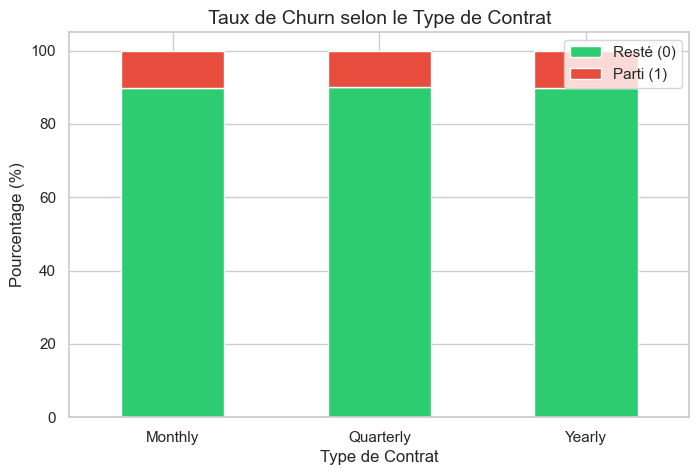

/var/folders/_4/jrm4bct12mbb49wpl6t1y9qh0000gn/T/ipykernel_31653/3695039165.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='support_tickets', palette=['#2ecc71', '#e74c3c'], ax=axes[0])


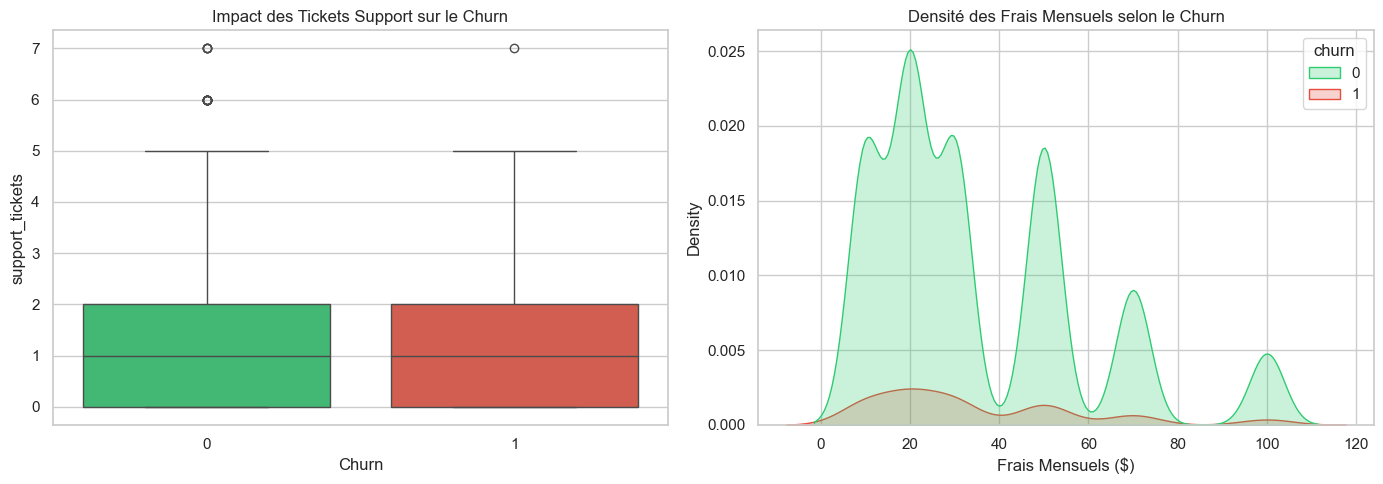

In [8]:
# 1. Variables Catégorielles vs Churn (Ex: Type de contrat)
plt.figure(figsize=(8, 5))
# pd.crosstab permet de calculer les proportions facilement
contract_churn = pd.crosstab(df['contract_type'], df['churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(8, 5))

plt.title("Taux de Churn selon le Type de Contrat", fontsize=14)
plt.ylabel("Pourcentage (%)")
plt.xlabel("Type de Contrat")
plt.legend(['Resté (0)', 'Parti (1)'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

# 2. Variables Numériques vs Churn (Ex: Tickets support et Frais mensuels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='churn', y='support_tickets', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title("Impact des Tickets Support sur le Churn")
axes[0].set_xlabel("Churn")

sns.kdeplot(data=df, x='monthly_fee', hue='churn', fill=True, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title("Densité des Frais Mensuels selon le Churn")
axes[1].set_xlabel("Frais Mensuels ($)")

plt.tight_layout()
plt.show()

### 6.6. Analyse Multivariée : Matrice de Corrélation

**Analyse visuelle :**
La carte de chaleur (heatmap) illustre les coefficients de corrélation de Pearson entre toutes nos variables numériques.
* On y recherche principalement les zones rouges foncées ou bleues foncées (corrélations fortes, proches de 1 ou -1).
* Sans surprise, on observe une corrélation structurelle très forte entre la durée de vie du client (`tenure_months`) et le revenu total généré (`total_revenue`), puisque ce dernier est mécaniquement le produit du temps par le prix mensuel.

**Conclusion Technique :**
Cette observation soulève un risque de **multicolinéarité**. Si deux variables apportent la même information mathématique, cela peut déstabiliser certains modèles linéaires comme la Régression Logistique. Lors de la phase de modélisation, si nous utilisons un algorithme linéaire, il sera peut-être pertinent de supprimer l'une de ces variables. En revanche, les algorithmes basés sur les arbres (comme Random Forest ou XGBoost) y sont naturellement insensibles.

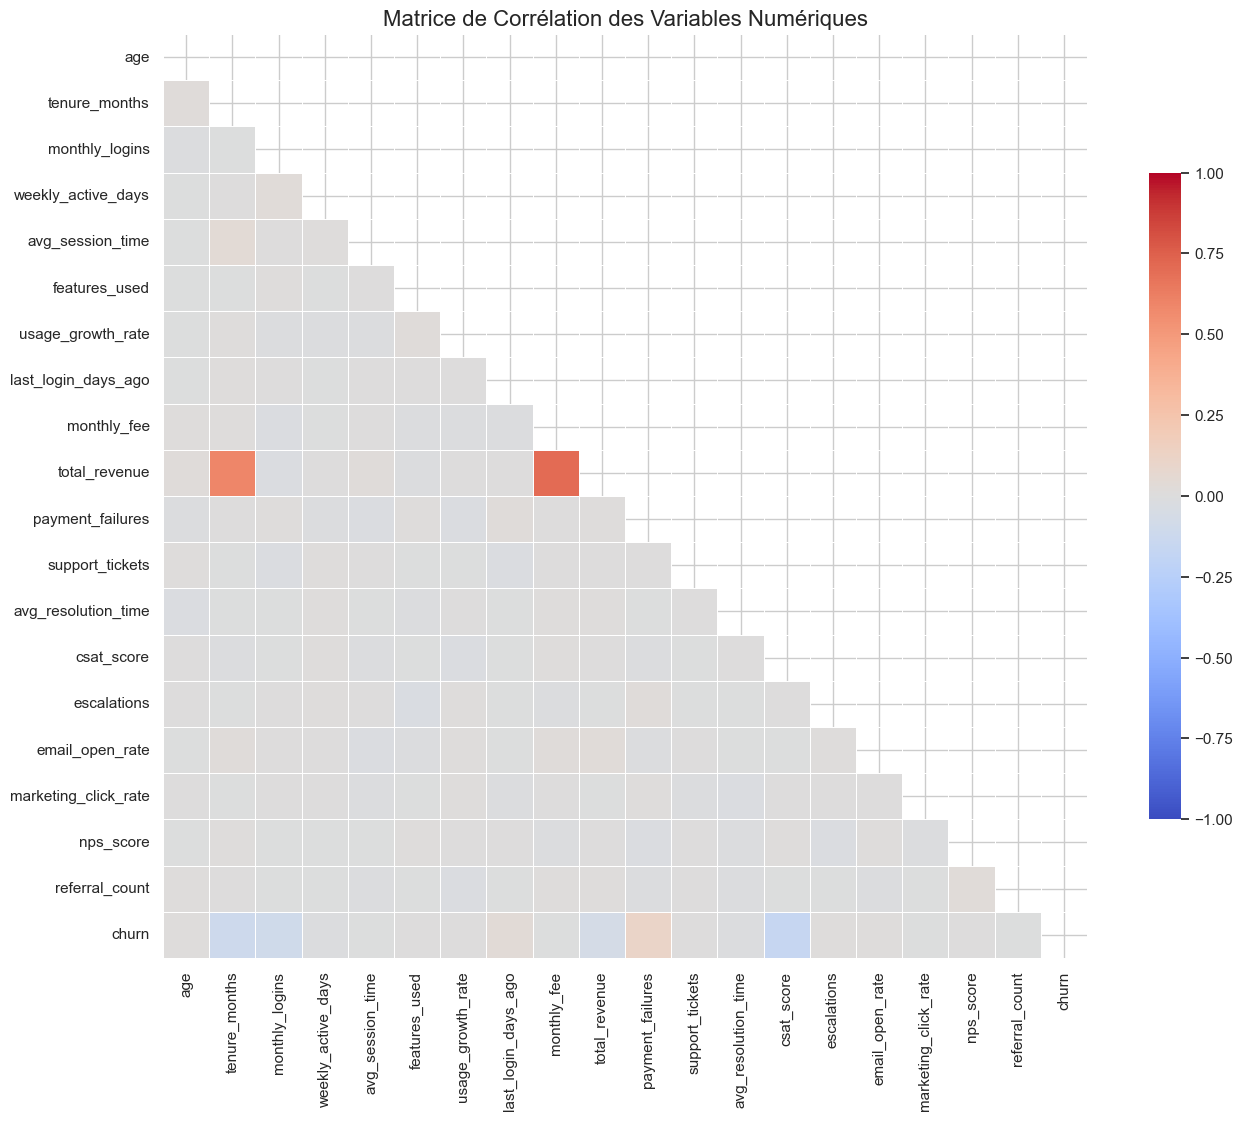

In [9]:
# On isole uniquement les variables numériques (calcul de corrélation impossible sur du texte)
df_numerique = df.select_dtypes(include=['int64', 'float64'])

# Calcul de la matrice de corrélation de Pearson
corr_matrix = df_numerique.corr()

# Création du masque pour cacher la moitié supérieure (redondante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            vmax=1, vmin=-1, 
            center=0,
            annot=False, # Mets True si tu veux afficher les chiffres, mais ça peut être illisible s'il y a trop de colonnes
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .7})

plt.title("Matrice de Corrélation des Variables Numériques", fontsize=16)
plt.show()

# Attention spéciale pour ton rapport : 
# Regarde bien la couleur entre 'tenure_months', 'monthly_fee' et 'total_revenue'.
# Elles risquent d'être très corrélées (Total = Mois * Prix_Mensuel).